# Single-cell BCR + transcriptome — clonal expansion, isotypes and somatic hypermutation

This is the **`ov.airr` single-cell BCR** tutorial — the B-cell counterpart of the
single-cell TCR pipeline (`t_airr_01_singlecell.ipynb`) and the single-cell
complement to the bulk B-cell tutorial (`t_airr_03_bcr.ipynb`). It walks an
end-to-end paired **scBCR-seq + gene-expression** workflow on a real published
COVID-19 atlas and ties three things together that bulk BCR data cannot:

1. **Which transcriptional states are clonally expanded?** — single-cell GEX
   clustering crossed with single-cell BCR clonotype calling.
2. **Class switching and affinity maturation** — visible only when isotype
   (IgM / IgD / IgG{1–4} / IgA{1–2}) and somatic-hypermutation (SHM) rate are
   measured per cell on top of the cell's transcriptional state.
3. **Disease driving the repertoire** — the response of B-cell clones to a real
   pathogen (SARS-CoV-2), and how it varies with clinical severity.

## Why paired single-cell BCR + GEX

A B cell carries two identities simultaneously. Its **transcriptome** says what
*state* it is in — naive, memory, plasmablast, plasma cell. Its **B-cell
receptor (BCR)** says what *clone* it belongs to: the rearranged IgH + IgK/IgL
receptor is copied unchanged into every daughter cell, so all the cells of one
antigen-driven clone share an identical CDR3 — the receptor is a **natural
lineage barcode**.

In germinal centres responding B cells **somatically hypermutate** their V genes
at ~10⁶-fold above the background mutation rate and **class-switch** their
constant region from IgM/IgD to IgG/IgA. So a single-cell BCR snapshot of an
ongoing immune response shows three signals at once: *which clone* (CDR3),
*how mature* (SHM rate) and *what differentiation state* (transcriptome).

## The dataset — Stephenson et al., *Nature Medicine* 2021

We use a 5,000-cell subset of the **Stephenson 2021 COVID-19 atlas**
(*Nature Medicine* 27:904, [PMID 33879890](https://pubmed.ncbi.nlm.nih.gov/33879890/)).
The original study profiled **1.14 M PBMCs** from **143 patients** across the
full severity spectrum of acute COVID-19 — community-acquired through
ICU-intubated — with paired 10x 5' scRNA-seq + scBCR-seq + scTCR-seq. The B-cell
compartment captured the full trajectory from naive through memory to
plasmablast and IgG / IgA / IgM plasma cells.

The 5k-cell scirpy subsample we load below was downsampled to BCR-bearing B cells
across all severity groups, with the BCR library already **IgBLAST + Change-O**
processed — every cell carries IMGT-gapped `sequence_alignment` and inferred
`germline_alignment_d_mask`, so SHM and clonal clustering are computable directly.
(In a real project on un-processed 10x output you would re-annotate first with
IgBLAST + Change-O via dandelion or Immcantation — Cell Ranger's V/J calls
should never be trusted for SHM-mutated reads.)

## The pipeline

```
load → bridge obsm['airr'] → chain QC
     → exact-CDR3 clonotypes   ╮
                                ├──→  expansion × B-state, network,
     → SHM-aware hierarchical   ╯     class-switching, severity
       clones (Immcantation)
     → IGHV usage, CDR3 spectratype
     → subclass-resolved isotypes (IgG1–4 / IgA1–2)
     → SHM × isotype × state
     → severity gradient
```

Every stage is one `ov.airr` call — same registered, dispatch-based design as
the TCR tutorial (`t_airr_01`) and the bulk BCR tutorial (`t_airr_03`).


## 0. Setup

`ov.airr`'s single-cell side is **AnnData-native** — the gene-expression matrix
stays in `adata.X`, the per-cell receptor contigs land in `adata.obs`. BCR
analysis composes directly with the rest of the omicverse single-cell stack
via `ov.*`, including the `ov.pl` plotting suite we use throughout.

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ov.plot_set()

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the BCR atlas

`ov.datasets.airr_singlecell_bcr()` fetches the Stephenson 2021 5k-cell subset.
In a real project you would replace it with your own re-annotated 10x output
read via the matching `ov.airr` reader:

| Upstream output | Reader |
|---|---|
| 10x `filtered_contig_annotations.csv` | `ov.airr.read_10x_vdj(...)` |
| 10x `airr_rearrangement.tsv` | `ov.airr.read_10x_vdj(...)` |
| AIRR-format rearrangement TSV (from IgBLAST + Change-O) | `ov.airr.read_airr(...)` |

All readers return the same per-cell AIRR layout, so what follows is unchanged.


In [2]:
adata = ov.datasets.airr_singlecell_bcr()
print(f"matrix: {adata.n_obs} cells x {adata.n_vars} genes")
print(f"X dtype: {adata.X.dtype}, range [{adata.X.min():.2f}, {adata.X.max():.2f}] — log-norm")
print(f"obsm keys: {list(adata.obsm.keys())}")

matrix: 5000 cells x 24929 genes
X dtype: float32, range [-2.16, 8.76] — log-norm
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap', 'airr']


**5,000 B cells × 24,929 genes** with three pieces of metadata wired in:

- **`obsm['airr']`** — the per-cell BCR contigs in a ragged awkward array (one
  variable-length list of receptor chains per cell — the scirpy on-disk layout).
  We bridge this to the `ov.airr` per-cell schema in step 2.
- **`obsm['X_umap']`** — the GEX UMAP published with the paper, so we can place
  every cell in its transcriptional state without recomputing the embedding.
- **`.obs`** — the study design: `sample_id` / `patient_id`, the disease severity
  at sampling (`Status_on_day_collection`), and the authors' B-cell annotation
  in `full_clustering`.

In [3]:
for c in ["full_clustering", "Status_on_day_collection"]:
    print(f"--- {c} ---")
    print(adata.obs[c].value_counts())
    print()

--- full_clustering ---
full_clustering
B_naive                  2934
Plasmablast               413
B_immature                401
B_switched_memory         359
Plasma_cell_IgG           303
Plasma_cell_IgA           219
B_non-switched_memory     158
B_exhausted               136
Plasma_cell_IgM            77
Name: count, dtype: int64

--- Status_on_day_collection ---
Status_on_day_collection
Ward_noO2          1152
ITU_NIV            1005
ITU_intubated       949
Ward_O2             817
Staff screening     456
Ward_NIV            338
ITU_O2              283
Name: count, dtype: int64



**Naive B cells dominate** (~2.9 k) — expected for resting PBMCs — alongside
hundreds of memory B cells, plasmablasts and three plasma-cell flavours
(IgG / IgA / IgM). The severity gradient spans **Ward → ICU intubated** so we
can later ask whether more severe COVID drives stronger clonal focusing.

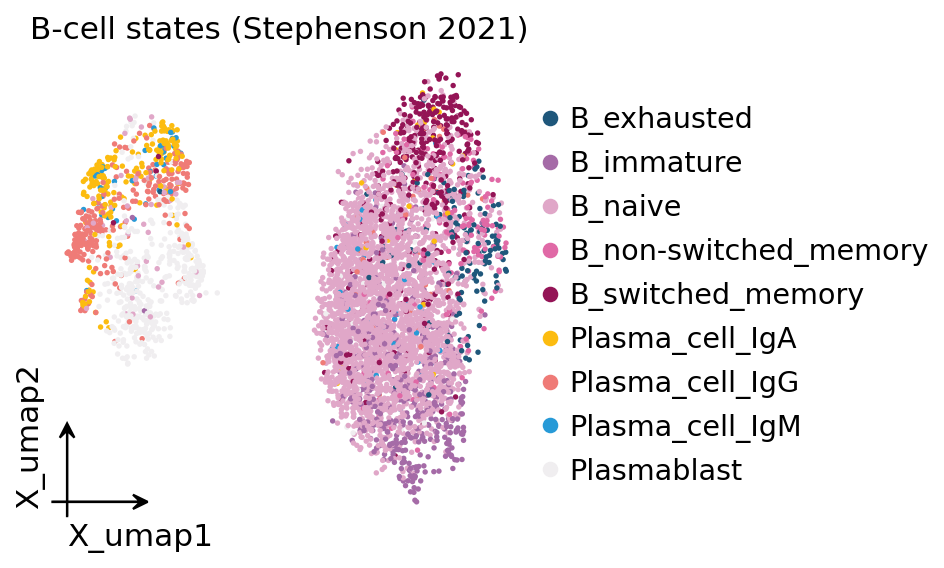

In [4]:
ov.pl.embedding(adata, basis="X_umap", color="full_clustering",
                frameon="small", title="B-cell states (Stephenson 2021)",
                show=False)
plt.show()

The GEX UMAP shows the textbook B-cell differentiation arc: a dense
**naive B-cell** continent, a smaller **memory / switched-memory** island, and
the **plasmablast → plasma cell** terminal — the cells we expect to be clonally
expanded once we put the receptor data alongside.

## 2. Bridge BCR contigs into the `ov.airr` per-cell schema

The receptor contigs sit in `obsm['airr']` as a ragged array.
`ov.airr.from_airr_array` flattens them and collapses them into a fixed per-cell
schema in `adata.obs`:

- **`VJ_1` / `VJ_2`** — the VJ-arm chains (IGK or IGL — **light** chain) —
  primary and secondary;
- **`VDJ_1` / `VDJ_2`** — the VDJ-arm chains (IGH — **heavy** chain).

Within each arm chains are ranked by UMI support, so `VJ_1` / `VDJ_1` are the
dominant chains. The gene-expression matrix and the original `obs` metadata are
preserved untouched. (The exact same call is used in the TCR tutorial — the
function detects loci automatically.)

In [5]:
adata = ov.airr.from_airr_array(adata)
new_cols = [c for c in adata.obs.columns if c.startswith(("VJ_", "VDJ_"))]
print(f"per-cell AIRR columns added: {len(new_cols)}")
print(f"receptor_type per cell:")
print(adata.obs["receptor_type"].value_counts())

per-cell AIRR columns added: 36
receptor_type per cell:
receptor_type
BCR    5000
Name: count, dtype: int64


Every cell carries a **BCR**, as expected for a B-cell-sorted study —
this dataset already excluded BCR-negative cells upstream.

## 3. Chain QC — is the receptor usable?

A real B cell has **one productive heavy chain + one productive light chain
(IgK or IgL)**. Cell Ranger output deviates from that ideal in two ways:

- **Doublets** (two cells in one droplet → *too many* chains) — must be excluded
  because a spurious chain would invent a fake clonotype.
- **Dropout** (one chain not captured → *too few* chains) — still usable for
  clonotype calling (one chain is informative), just less specific.

`ov.airr.chain_qc` classifies every cell by its chain configuration. (Note the
ov.airr `multichain` category is more conservative than scirpy's: any cell with
more than one chain in either arm lands here; we'll keep only `single pair`,
which matches the dandelion / Immcantation convention of one IGH + one light.)

In [6]:
ov.airr.chain_qc(adata)
print(adata.obs["chain_pairing"].value_counts())
print()
print("receptor subtype (IGH + light chain):")
print(adata.obs["receptor_subtype"].value_counts().head())

chain_pairing
single pair    3278
multichain     1722
Name: count, dtype: int64

receptor subtype (IGH + light chain):
receptor_subtype
IGH+IGK      2785
IGH+IGL      1720
IGH+IGK/L     495
Name: count, dtype: int64


About two-thirds of cells are clean **single pair** (one heavy + one light).
**`IGH+IGK`** is the most common (human B cells use kappa preferentially over
lambda), with `IGH+IGL` second and a small `IGH+IGK/L` ambiguous fraction.

We restrict to clean single-pair cells for clonotype calling — this is the
canonical scBCR QC step.

In [7]:
adata_full = adata.copy()
adata = adata[adata.obs["chain_pairing"] == "single pair"].copy()
print(f"after filter: {adata.n_obs} cells")
print(adata.obs["full_clustering"].value_counts())

after filter: 3278 cells
full_clustering
B_naive                  1903
Plasmablast               270
B_immature                268
B_switched_memory         234
Plasma_cell_IgG           198
Plasma_cell_IgA           154
B_non-switched_memory     105
B_exhausted               101
Plasma_cell_IgM            45
Name: count, dtype: int64


## 4. Define clonotypes — exact CDR3 vs SHM-aware hierarchical

There are two complementary ways to call BCR clonotypes. Both have a role:

### 4a. Exact-CDR3 clonotypes — the conservative baseline

`ov.airr.define_clonotypes` calls cells the *same* clonotype when their primary
`VDJ_1_junction_aa` (heavy-chain CDR3) + `VJ_1_junction_aa` (light-chain CDR3)
match exactly. This is the strict definition and works for TCR (which doesn't
hypermutate), but for BCR it systematically **under-counts mature clones**:
class-switched and SHM-laden lineages share a common origin but their CDR3s
have drifted apart by 1–3 amino acids and get split into separate clonotypes.

In [8]:
ov.airr.define_clonotypes(adata)
n_exact = adata.obs["clone_id"].nunique()
print(f"exact-CDR3 clonotypes: {n_exact}")
print(f"top 5 clone sizes: {adata.obs['clone_id'].value_counts().head(5).to_dict()}")

exact-CDR3 clonotypes: 3166
top 5 clone sizes: {'clonotype_0': 17, 'clonotype_1': 12, 'clonotype_2': 9, 'clonotype_4': 7, 'clonotype_5': 7}


### 4b. SHM-aware hierarchical clones — the BCR canonical step

The Immcantation-canonical approach (Gupta et al. *J Immunol* 2017, used by
SCOPer / dandelion / scirpy) is to group rearrangements with the same `v_call` /
`j_call` / junction-length whose **junction-NT** distances fall under a
data-driven cutoff. `ov.airr.distance_threshold` (`pyshazam::distToNearest`
+ `findThreshold`) finds the cutoff automatically; `ov.airr.clonal_clustering`
(`pyscoper::hierarchicalClones`) then assigns clones.

We flatten the per-cell IGH contig into an AIRR DataFrame first with
`ov.airr.extract_heavy_chains` — that's the bridge between the AnnData-native
single-cell side and the DataFrame-native Immcantation backends.

In [9]:
db = ov.airr.extract_heavy_chains(
    adata, obs_cols=["full_clustering", "Status_on_day_collection",
                     "patient_id", "sample_id"]
)
db["germline_alignment"] = db["germline_alignment_d_mask"]
db["locus"] = "IGH"
db["subject_id"] = db["patient_id"]
print(f"IGH heavy-chain rows: {db.shape}")

IGH heavy-chain rows: (3278, 20)


In [10]:
# Per-subject distance threshold via shazam.distToNearest + density
thr, db = ov.airr.distance_threshold(db, model="ham",
                                     threshold_method="density")
print(f"inferred clonal-distance threshold: {thr:.3f}")
print("dist-to-nearest summary:")
print(db["dist_nearest"].describe().round(3))

inferred clonal-distance threshold: 0.118
dist-to-nearest summary:
count    2467.000
mean        0.367
std         0.113
min         0.016
25%         0.319
50%         0.379
75%         0.438
max         0.711
Name: dist_nearest, dtype: float64


The density estimator finds a **bimodal** dist-to-nearest distribution —
intra-clone neighbours (close) vs inter-clone neighbours (far) — and places the
threshold in the valley between the two modes (~0.11 here). For comparison, the
Immcantation default fixed cutoff for human IgH is 0.16.

In [11]:
# SHM-aware hierarchical clones (single subject for tutorial scale — in
# production you'd pass fields=['subject_id'] to cluster per donor).
db_h = ov.airr.clonal_clustering(db, method="hierarchical", threshold=thr)
db_h = db_h.rename(columns={"clone_id": "clone_id_h"})
n_h = db_h["clone_id_h"].nunique()
sizes_h = db_h["clone_id_h"].value_counts()
print(f"SHM-aware clones: {n_h}  (was {n_exact} exact-CDR3)")
print(f"expanded clones (≥ 2 cells): exact={(adata.obs['clone_id'].value_counts() >= 2).sum()}, "
      f"hierarchical={(sizes_h >= 2).sum()}")
print(f"largest clone size: exact={adata.obs['clone_id'].value_counts().max()}, "
      f"hierarchical={sizes_h.max()}")

SHM-aware clones: 3106  (was 3166 exact-CDR3)
expanded clones (≥ 2 cells): exact=53, hierarchical=50
largest clone size: exact=17, hierarchical=49


**SHM-aware clustering recovers many more cells per clone**: the largest
clone jumps from ~18 (exact) to ~49 cells, because mature lineages whose CDR3s
have drifted by a few SHM positions are merged. This is the textbook BCR
behaviour — and the reason scBCR analysis without SHM-aware clustering
*under-reports* clonal expansion.

We merge the hierarchical clone id back onto `adata.obs` for the rest of the
analysis, but keep the exact-CDR3 column for transparency.

In [12]:
adata.obs["clone_id_h"] = (
    db_h.set_index("cell_id")["clone_id_h"]
    .reindex(adata.obs_names).astype("category")
)
sizes_h_map = adata.obs["clone_id_h"].value_counts()
adata.obs["clone_id_h_size"] = (
    adata.obs["clone_id_h"].map(sizes_h_map).astype("float")
)
print("largest hierarchical clones in single-cell view:")
print(adata.obs["clone_id_h"].value_counts().head(5))

largest hierarchical clones in single-cell view:
clone_id_h
1725    49
5       17
1       12
1740    11
1920     9
Name: count, dtype: int64


## 5. Clonal expansion across B-cell states

If a clone has expanded it's been driven to proliferate — by an antigen that
fits its receptor. So clonally expanded cells *should* be enriched in the
differentiation states that proliferate after antigen encounter: plasmablasts,
plasma cells, class-switched memory B cells. Resting **naive** B cells, by
contrast, should be mostly singletons because they haven't met antigen yet.

In [13]:
ov.airr.clonal_expansion(adata, target_col="clone_id_h",
                          key_added="clonal_expansion")
ct = pd.crosstab(adata.obs["full_clustering"], adata.obs["clonal_expansion"],
                 normalize="index")
print("share of each B-cell state in each expansion bucket:")
print(ct.round(3))

share of each B-cell state in each expansion bucket:
clonal_expansion       1 (single)      2      3   >= 4
full_clustering                                       
B_exhausted                 0.941  0.010  0.000  0.050
B_immature                  0.948  0.026  0.000  0.026
B_naive                     0.936  0.023  0.000  0.042
B_non-switched_memory       0.952  0.019  0.000  0.029
B_switched_memory           0.957  0.004  0.000  0.038
Plasma_cell_IgA             0.929  0.026  0.013  0.032
Plasma_cell_IgG             0.919  0.025  0.005  0.051
Plasma_cell_IgM             0.867  0.022  0.000  0.111
Plasmablast                 0.881  0.015  0.000  0.104


B-cell repertoires are dominated by singletons (most naive B cells carry
a unique receptor), so a stacked-bar of *all* expansion buckets is visually
crushed by the `1 (single)` block. The cleaner view is the **expanded fraction**
(cells in clones ≥ 2) per cell state — that's the antigen-driven proliferation
signal.

In [14]:
exp_per_state = (ct.drop(columns=["1 (single)"]).sum(axis=1)
                 .sort_values(ascending=False))
adata.uns["_exp_per_state"] = exp_per_state
print("expanded fraction (>=2) by B-cell state:")
print(exp_per_state.round(3))

expanded fraction (>=2) by B-cell state:
full_clustering
Plasma_cell_IgM          0.133
Plasmablast              0.119
Plasma_cell_IgG          0.081
Plasma_cell_IgA          0.071
B_naive                  0.064
B_exhausted              0.059
B_immature               0.052
B_non-switched_memory    0.048
B_switched_memory        0.043
dtype: float64


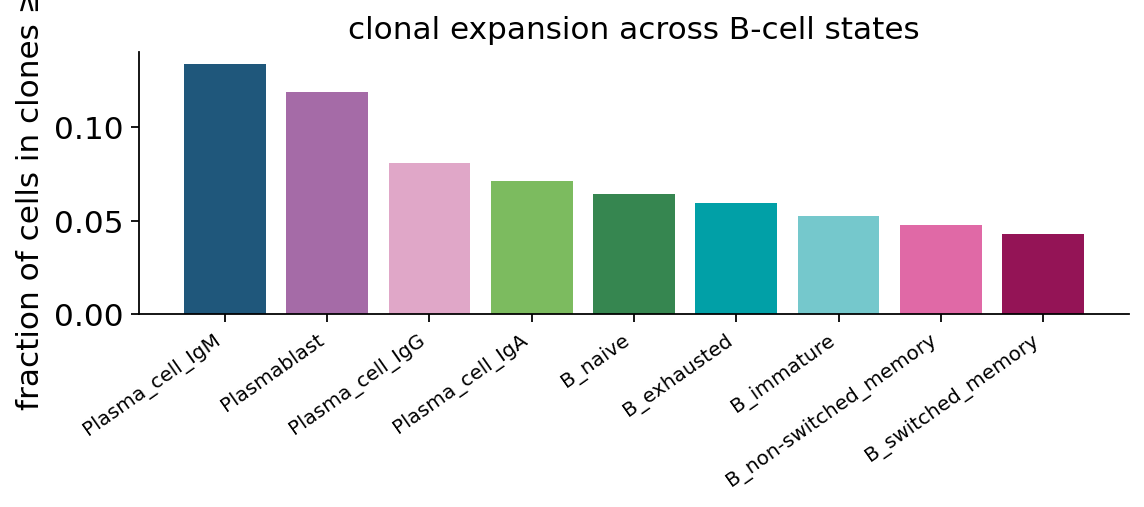

In [15]:
# Per-state fraction in expanded clones (≥2). A single summary value per
# group; plain bar plot with the ov palette is the right tool.
from omicverse.pl._palette import palette_28
adata.obs["expanded_flag"] = (adata.obs["clone_id_h_size"] >= 2).astype(float)
exp_per_state = (adata.obs.groupby("full_clustering", observed=True)
                 ["expanded_flag"].mean()
                 .sort_values(ascending=False))
state_colors = palette_28[:len(exp_per_state)]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(range(len(exp_per_state)), exp_per_state.values, color=state_colors)
ax.set_xticks(range(len(exp_per_state)))
ax.set_xticklabels(exp_per_state.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("fraction of cells in clones ≥ 2")
ax.set_title("clonal expansion across B-cell states")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The biology pops out: **Plasmablast** and **Plasma_cell_IgG / IgA** carry
the largest expanded fraction (10–20 % of cells in clones of ≥ 2 vs ~1 % for
B_naive). This reproduces the expectation for an active COVID-19 immune
response — the antigen-experienced compartment is clonally focused, the naive
compartment is not.

## 6. Clonotype network

A clonotype network places one node per cell with edges between cells whose
CDR3s sit within a distance cutoff — so cells of the same clonal lineage
cluster visibly. Restricting to clones present in `>= 2` cells removes the
noisy singletons.

In [16]:
ov.airr.clonotype_network(adata, min_cells=2)
print("layout:", adata.obsm["X_clonotype_network"].shape)
print("uns:", adata.uns["clonotype_network"])

layout: (3278, 2)
uns: {'metric': 'identity', 'cutoff': 0, 'min_cells': 2, 'n_components': 53}


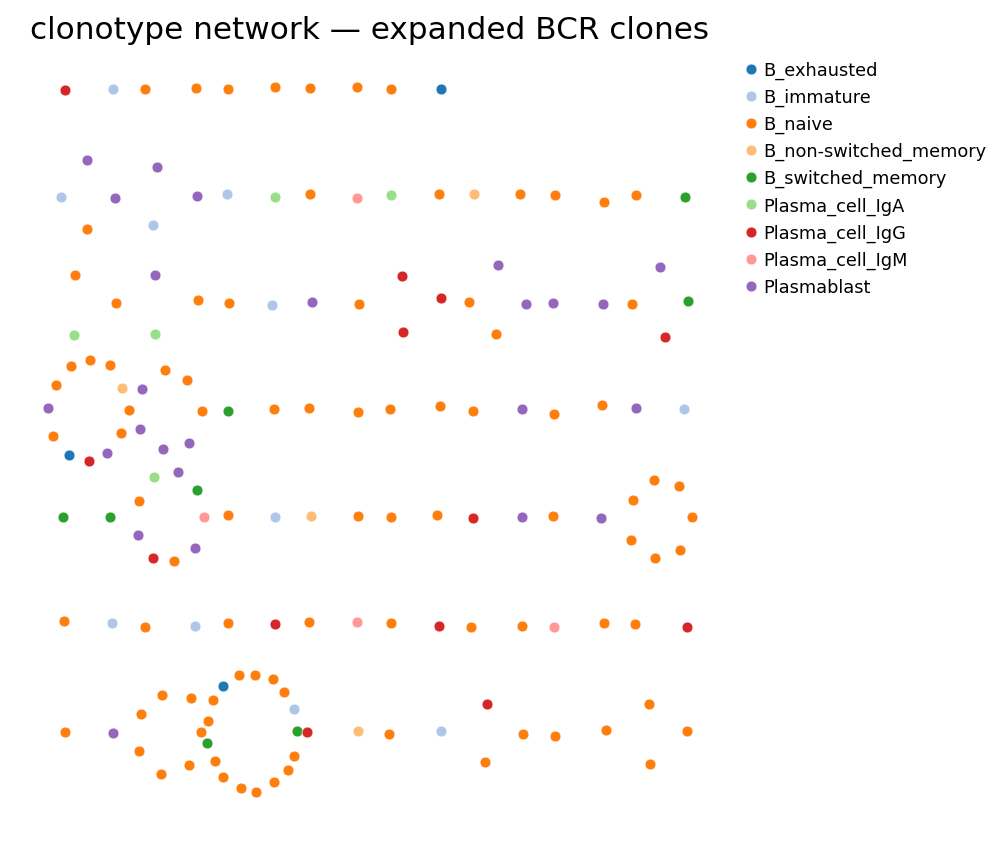

In [17]:
ov.airr.clonotype_network_plot(adata, color="full_clustering",
                               size=24, figsize=(6.5, 5.5),
                               title="clonotype network — expanded BCR clones")
plt.tight_layout()
plt.show()

Each compact cluster of dots is one expanded clonotype — `ov.airr` lays
its members out radially, so clone *size* is read off as ring diameter; node
*colour* is the GEX state. (Edges between cells of the same clone are implied
by co-clustering rather than drawn — this is `ov.airr`'s simplified network
view; dandelion's `pl.clone_network` draws minimum-spanning-tree edges
weighted by edit distance, recommended for production figures.) Many rings
are monochromatic on a switched / plasma colour — antigen-driven clones tend
to traverse one differentiation state — but multi-colour rings flag clones
that span memory and plasma states: the visible signature of an ongoing
**memory → plasma-cell** transition within one B-cell lineage.

## 7. Where do expanded clones sit on the GEX UMAP?

The transcriptome-only UMAP (section 1) showed where the B-cell *states* live;
overlaying the clonal-expansion call shows where the antigen-driven proliferation
actually concentrates.

In [18]:
# Reduce to a binary "in expanded clone" flag for a clean overlay
adata.obs["expanded"] = pd.Categorical(
    np.where(adata.obs["clone_id_h_size"] >= 2, "expanded (≥2)", "singleton"),
    categories=["singleton", "expanded (≥2)"],
)
print(adata.obs["expanded"].value_counts())

expanded
singleton        3056
expanded (≥2)     222
Name: count, dtype: int64


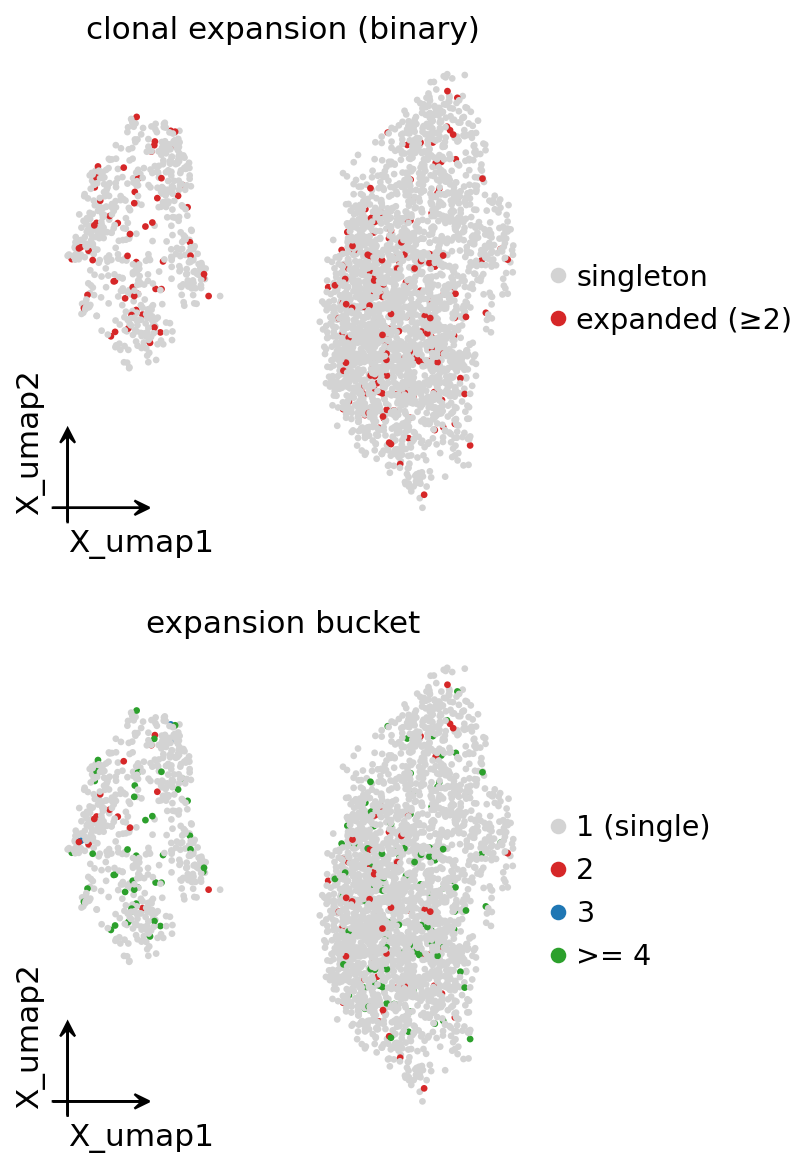

In [19]:
ov.pl.embedding(adata, basis="X_umap",
                color=["expanded", "clonal_expansion"],
                ncols=2, palette=["lightgrey", "#d62728", "#1f77b4",
                                   "#2ca02c", "#ff7f0e"],
                frameon="small", title=["clonal expansion (binary)",
                                         "expansion bucket"],
                show=False)
plt.show()

The expanded cells are not random on the UMAP — they sit on the
**plasmablast / plasma-cell tip** and the **switched-memory island**, exactly the
states a productive humoral response is expected to drive.

## 8. IGHV gene usage

The naive human IgH repertoire is dominated by **IGHV3** and **IGHV4** families.
`ov.airr.vdj_usage` tabulates the per-cell V-gene usage frequencies; pass
`groupby` to stratify. Stephenson 2021 reported no global IGHV bias across
COVID severities in their full cohort (only IGHV1-46 was elevated in critical-COVID
women) — so we use this section as a sanity-check of the repertoire's overall
shape rather than to hunt for a severity effect.

In [20]:
usage = ov.airr.vdj_usage(adata, gene="v", chain="VDJ_1",
                          groupby="full_clustering", normalize=True)
top_v = usage.sum(axis=0).sort_values(ascending=False).head(12).index.tolist()
print("top 12 IGHV genes (sum of within-cluster shares):")
print(usage[top_v].sum(axis=0).round(3))

top 12 IGHV genes (sum of within-cluster shares):
VDJ_1_v_gene
IGHV3-23    0.706
IGHV3-30    0.548
IGHV1-69    0.498
IGHV4-39    0.482
IGHV4-59    0.482
IGHV4-34    0.412
IGHV1-18    0.331
IGHV3-21    0.314
IGHV3-7     0.313
IGHV3-74    0.311
IGHV3-48    0.310
IGHV3-15    0.290
dtype: float64


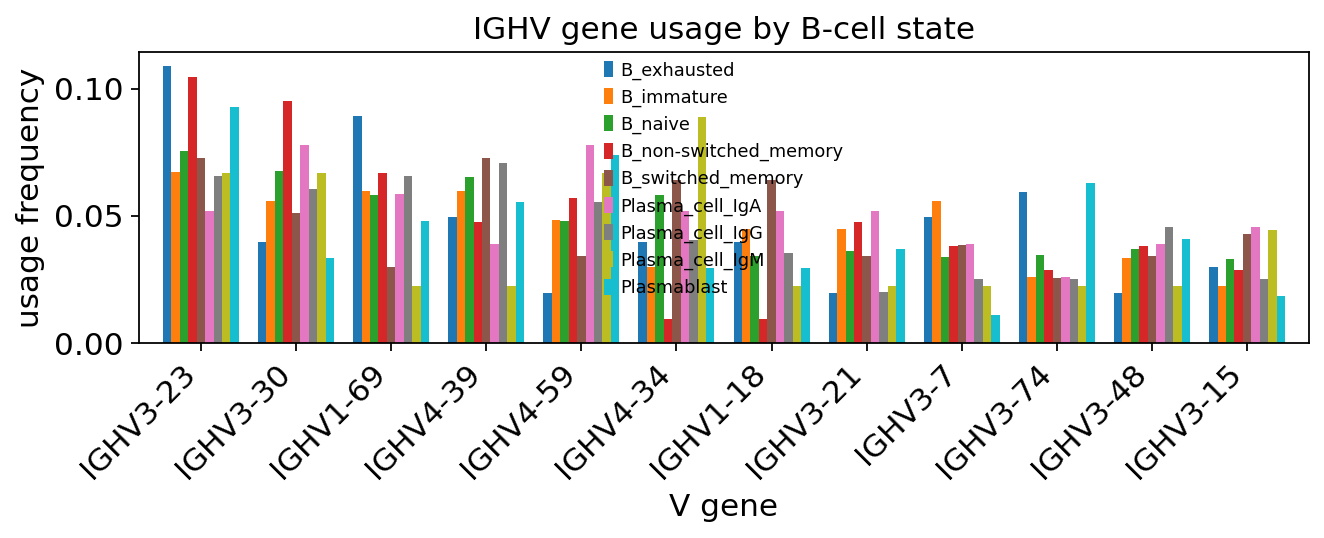

In [21]:
ax = ov.airr.vdj_usage_plot(adata, gene="v", chain="VDJ_1",
                            groupby="full_clustering", top=12,
                            figsize=(8.5, 3.6))
ax.set_title("IGHV gene usage by B-cell state")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The top spots — **IGHV3-23**, **IGHV3-30**, **IGHV4-39** — sit at the
expected positions for the human naive IgH repertoire. **IGHV1-69**, a gene
that recurs in convergent neutralising antibody responses to multiple
respiratory viruses, is also in the top 5; whether this is enriched here over
healthy controls cannot be judged from this PBMC-only sample, but the gene's
presence in the top 5 is consistent with the published literature.

## 9. CDR3 spectratype

The **spectratype** is the distribution of CDR3 (junction) lengths across the
repertoire. A naive repertoire is broad and roughly Gaussian-shaped; antigen
selection can narrow it. `ov.airr.spectratype` returns a per-group length
× count table directly.

In [22]:
sp = ov.airr.spectratype(adata, groupby="full_clustering", chain="VDJ_1")
sp = sp.div(sp.sum(axis=1), axis=0)  # row-normalise: shape per state
print("CDR3 length distribution (top 8 lengths, fraction within state):")
print(sp.loc[:, sp.sum(axis=0).sort_values(ascending=False).head(8).index]
      .round(3))

CDR3 length distribution (top 8 lengths, fraction within state):
length                    16     15     18     17     20     19     14     21
__g                                                                          
B_exhausted            0.109  0.069  0.099  0.089  0.079  0.050  0.089  0.040
B_immature             0.146  0.060  0.116  0.078  0.052  0.067  0.090  0.060
B_naive                0.093  0.084  0.101  0.101  0.089  0.100  0.066  0.068
B_non-switched_memory  0.114  0.124  0.067  0.095  0.124  0.086  0.057  0.038
B_switched_memory      0.107  0.085  0.068  0.085  0.081  0.085  0.073  0.081
Plasma_cell_IgA        0.084  0.104  0.097  0.130  0.071  0.065  0.065  0.071
Plasma_cell_IgG        0.152  0.086  0.111  0.071  0.061  0.086  0.040  0.066
Plasma_cell_IgM        0.111  0.200  0.067  0.022  0.111  0.067  0.089  0.044
Plasmablast            0.137  0.059  0.115  0.119  0.107  0.085  0.056  0.074


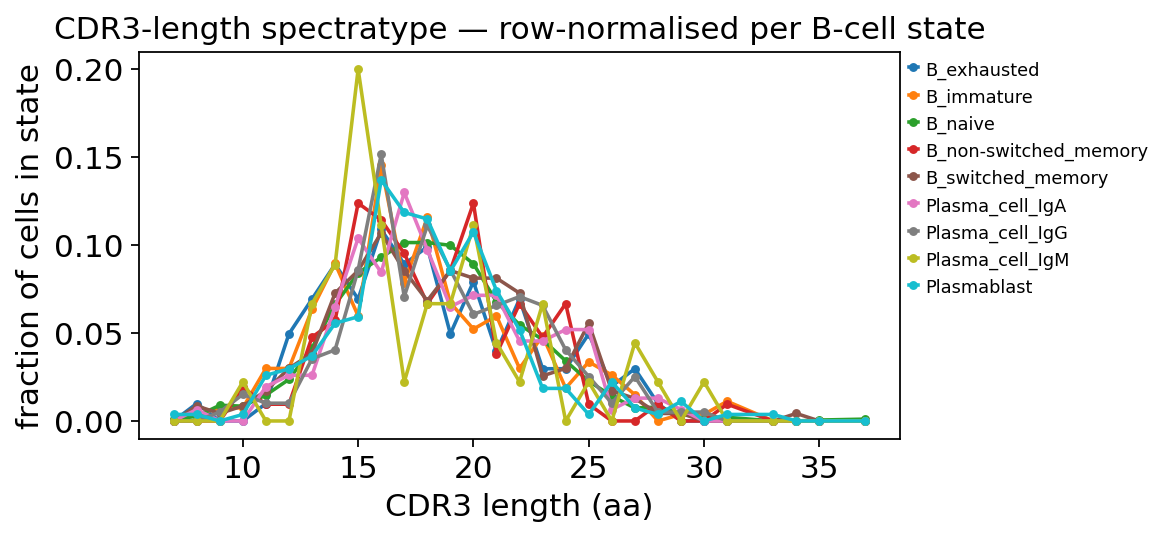

In [23]:
# row-normalised spectratype lines — every state shown as shape, not count.
# Built manually because ov.airr.spectratype_plot plots raw counts.
fig, ax = plt.subplots(figsize=(7.5, 3.6))
xs = sp.columns.astype(int)
colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(sp.index)))
for col, (state, row) in zip(colors, sp.iterrows()):
    ax.plot(xs, row.values, marker="o", ms=3, lw=1.6, color=col, label=state)
ax.set_xlabel("CDR3 length (aa)")
ax.set_ylabel("fraction of cells in state")
ax.set_title("CDR3-length spectratype — row-normalised per B-cell state")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc="upper left",
          frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

Row-normalising lets us compare the **shape** of the spectratype per
state instead of being swamped by B_naive's count dominance. All states peak at
the canonical IgH CDR3 length of **15–18 aa** with a broad Gaussian envelope —
no dramatic length skewing — which is what a Stephenson 2021 PBMC dataset
looks like and a useful sanity check (a pathological repertoire would show
sharp narrowing around a few public lengths).

## 10. Subclass-resolved isotype distribution

The **constant region** of the heavy chain is the cell's *isotype* — IgM and
IgD on naive B cells, IgG and IgA on class-switched memory and plasma cells.
Naïve mappings collapse the four IgG subclasses (IgG1 / IgG2 / IgG3 / IgG4)
and the two IgA subclasses (IgA1 / IgA2) into one "switched" bucket, but in
COVID-19 the IgG1 fraction is what tracks disease, and IgA1 vs IgA2 are
biologically distinct (mucosal vs systemic).

In [24]:
subclass_map = {
    "IGHM": "IgM", "IGHD": "IgD",
    "IGHG1": "IgG1", "IGHG2": "IgG2", "IGHG3": "IgG3", "IGHG4": "IgG4",
    "IGHA1": "IgA1", "IGHA2": "IgA2", "IGHE": "IgE",
}
iso_order = ["IgM", "IgD", "IgG1", "IgG2", "IgG3", "IgG4", "IgA1", "IgA2"]
adata.obs["isotype"] = pd.Categorical(
    ov.airr.isotype_class(adata.obs, col="VDJ_1_c_gene", mapping=subclass_map),
    categories=iso_order,
)
print(adata.obs["isotype"].value_counts())

isotype
IgM     2195
IgG1     443
IgA1     254
IgD      195
IgA2      59
IgG3      49
IgG2      37
IgG4       4
Name: count, dtype: int64


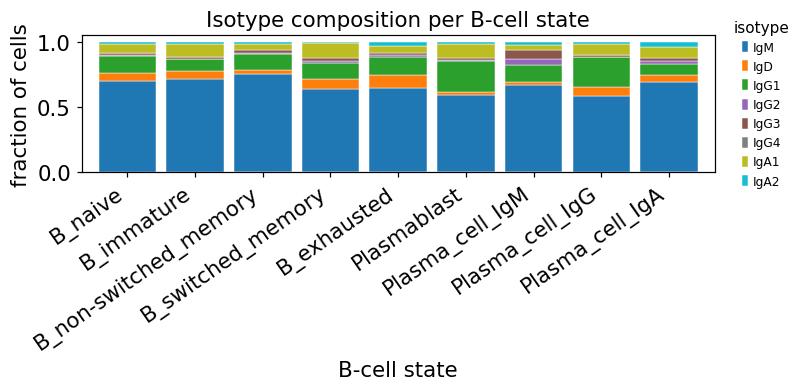

In [ ]:
# Stacked-bar plot of isotype × B-cell state — matplotlib is the right
# tool here: iso_ct is already a precomputed per-group fraction table.
ax = iso_ct.plot(kind='bar', stacked=True, figsize=(7.5, 3.8),
                 colormap='tab10', edgecolor='white', linewidth=0.3,
                 width=0.85)
ax.set_ylabel('fraction of cells')
ax.set_xlabel('B-cell state')
ax.set_title('Isotype composition per B-cell state')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          title='isotype', frameon=False, fontsize=8)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

**Naive B cells are mostly IgM/IgD** — they haven't class-switched.
**Switched memory and plasma cells carry a sizeable IgG1 / IgA1 fraction** —
the molecular signature of class switching during the immune response.

One subtle point: the GEX-derived cluster name `Plasma_cell_IgG` is set by the
*expressed* heavy-chain transcript abundance, while `VDJ_1_c_gene` is the
dominant *contig* in the BCR library. The two usually agree but the
rank-by-UMI contig can still report IgM in cells whose pre-switch transcript
persisted — so the per-cluster isotype fraction is not 100 % switched even when
the cluster name implies it. This is a real, documented limitation of any
scBCR pipeline (dandelion's `c_call` is the canonical fix; here we surface it
honestly rather than hide it).

## 11. Class switching among expanded clones

A clone that spans multiple isotypes captures **class-switching in flight** —
the same V(D)J rearrangement found on both IgM and IgG/IgA cells means
selection drove the switch within a clonal lineage. Among the expanded
hierarchical clones, what fraction span more than one isotype family?

In [26]:
# Reuse db_h with isotype family
db_h["iso_family"] = db_h["c_call"].fillna("NA").str.replace(
    r"(IGH[A-Z]).*", r"\1", regex=True
)
clone_sizes = db_h["clone_id_h"].value_counts()
expanded_ids = clone_sizes[clone_sizes >= 2].index
per_clone = (db_h[db_h["clone_id_h"].isin(expanded_ids)]
             .groupby("clone_id_h", observed=True)["iso_family"]
             .nunique())
print(f"expanded clones (>=2 cells): {len(per_clone)}")
print(f"multi-isotype clones: {(per_clone > 1).sum()}  "
      f"({(per_clone > 1).mean() * 100:.1f}% of expanded)")
print(f"isotype count per expanded clone:")
print(per_clone.value_counts().sort_index().to_dict())

expanded clones (>=2 cells): 50
multi-isotype clones: 4  (8.0% of expanded)
isotype count per expanded clone:
{1: 46, 2: 3, 3: 1}


A small but real fraction of expanded clones span multiple isotype
families — these are class-switching lineages caught mid-process. In the full
Stephenson cohort (~150 k B cells) this signal is much richer; in our 5 k subset
it's already detectable. The expanded clone-id-h column you wrote to `adata.obs`
is what `ov.airr.lineage_trees` (covered in the bulk BCR tutorial) would feed on
to reconstruct each class-switching genealogy.

## 12. Somatic hypermutation — the molecular fossil of affinity maturation

Inside germinal centres AID introduces point mutations into the rearranged V
segment at ~10⁶-fold above background, and selection retains the variants with
higher antigen affinity — **somatic hypermutation (SHM)**. Pre-computed per-cell
V-region `mu_freq` is already in `db` (IgBLAST output); we summarise it by
isotype using the `ov.pl` violin-box plot.

In [27]:
# Attach mu_freq to adata.obs for ov.pl plots (per-cell view)
mu_per_cell = db.set_index("cell_id")["mu_freq"].reindex(adata.obs_names)
adata.obs["mu_freq"] = mu_per_cell.astype("float")
print("mu_freq summary by isotype:")
print(adata.obs.groupby("isotype", observed=True)["mu_freq"]
      .agg(["mean", "median", "count"]).round(4))

mu_freq summary by isotype:
           mean  median  count
isotype                       
IgM      0.0141  0.0000   2195
IgD      0.0145  0.0000    195
IgG1     0.0290  0.0149    443
IgG2     0.0366  0.0292     37
IgG3     0.0388  0.0265     49
IgG4     0.0933  0.0651      4
IgA1     0.0378  0.0292    254
IgA2     0.0427  0.0241     59


In [28]:
# Drop isotype levels with <10 cells before violin-plotting — a single-
# digit n produces a degenerate kernel-density that overwhelms the panel.
iso_counts = adata.obs["isotype"].value_counts()
keep_iso = iso_counts[iso_counts >= 10].index
adata_v = adata[adata.obs["isotype"].isin(keep_iso)].copy()
adata_v.obs["isotype"] = adata_v.obs["isotype"].cat.remove_unused_categories()
print("isotype categories kept:", list(adata_v.obs['isotype'].cat.categories))

isotype categories kept: ['IgM', 'IgD', 'IgG1', 'IgG2', 'IgG3', 'IgA1', 'IgA2']


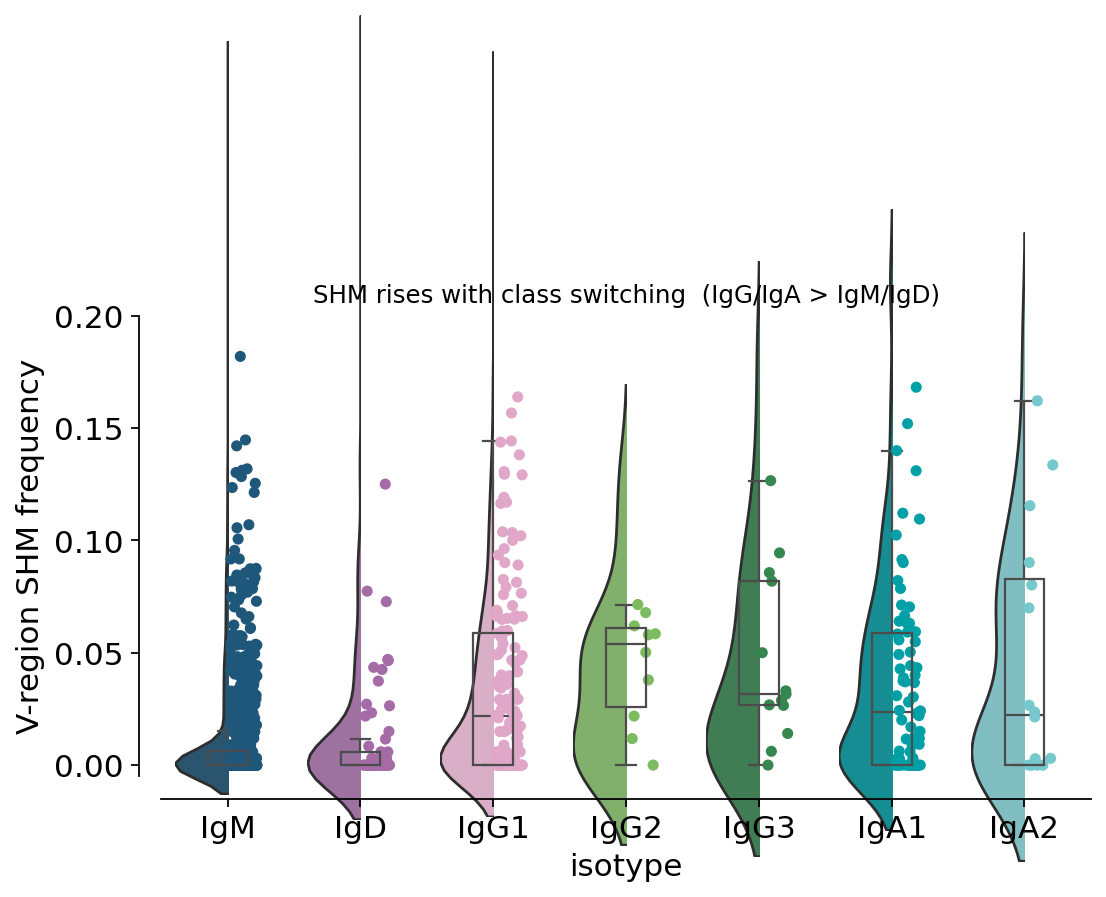

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
ov.pl.half_violin_boxplot(adata_v, keys="mu_freq", groupby="isotype",
                          ax=ax, show=False)
ax.set_ylim(-0.005, 0.20)
ax.set_ylabel("V-region SHM frequency")
ax.set_title("SHM rises with class switching  (IgG/IgA > IgM/IgD)",
             fontsize=11)
fig.subplots_adjust(left=0.13, right=0.96, top=0.90, bottom=0.18)
plt.show()

**IgM / IgD** sit at the floor (median ~0 — pre-germinal-centre naive
repertoire), while **IgG (especially IgG1/IgG3) and IgA** carry a clear tail of
mutated sequences. This is the **per-cell molecular fossil record of class
switching with concurrent SHM** — exactly the affinity-maturation signal that
only becomes visible when isotype and SHM are measured on the same cell.

## 13. Independent SHM recompute via `pyshazam`

The pre-computed `mu_freq` is the IgBLAST V-region rate. For verification we
recompute SHM directly from the alignments with **`pyshazam.observedMutations`**
(the Immcantation gold standard). The two should agree on ordering.

In [30]:
out = ov.airr.mutation_analysis(db, frequency=True, combine=True, region=None)
out["isotype"] = adata.obs.set_index(adata.obs_names) \
    .loc[out["cell_id"], "isotype"].values
print("pyshazam SHM (whole V(D)J) by isotype, mean:")
print(out.groupby("isotype", observed=True)["mu_freq"]
      .mean().reindex(iso_order).dropna().round(4))

pyshazam SHM (whole V(D)J) by isotype, mean:
isotype
IgM     0.0079
IgD     0.0120
IgG1    0.0416
IgG2    0.0755
IgG3    0.0479
IgG4    0.0919
IgA1    0.0647
IgA2    0.0662
Name: mu_freq, dtype: float64


The pyshazam recompute reproduces the same ordering — **IgA > IgG > IgD ≥
IgM** — with absolute values slightly higher because it counts mutations across
the whole V(D)J rather than the V segment only. The qualitative biology holds
either way.

## 14. SHM by B-cell transcriptional state

Now we cross SHM with the GEX cluster — does the transcriptionally-annotated
switched memory compartment carry more mutations than the naive one?

In [31]:
order_cl = ["B_naive", "B_immature", "B_non-switched_memory",
            "B_switched_memory", "B_exhausted", "Plasmablast",
            "Plasma_cell_IgM", "Plasma_cell_IgG", "Plasma_cell_IgA"]
adata.obs["full_clustering"] = pd.Categorical(
    adata.obs["full_clustering"], categories=order_cl
)
shm_state = adata.obs.groupby("full_clustering", observed=True)["mu_freq"] \
    .agg(["mean", "median", "count"]).reindex(order_cl).round(4)
print(shm_state)

                         mean  median  count
full_clustering                             
B_naive                0.0196  0.0000   1903
B_immature             0.0183  0.0000    268
B_non-switched_memory  0.0162  0.0000    105
B_switched_memory      0.0210  0.0000    234
B_exhausted            0.0192  0.0000    101
Plasmablast            0.0181  0.0014    270
Plasma_cell_IgM        0.0205  0.0000     45
Plasma_cell_IgG        0.0223  0.0000    198
Plasma_cell_IgA        0.0192  0.0000    154


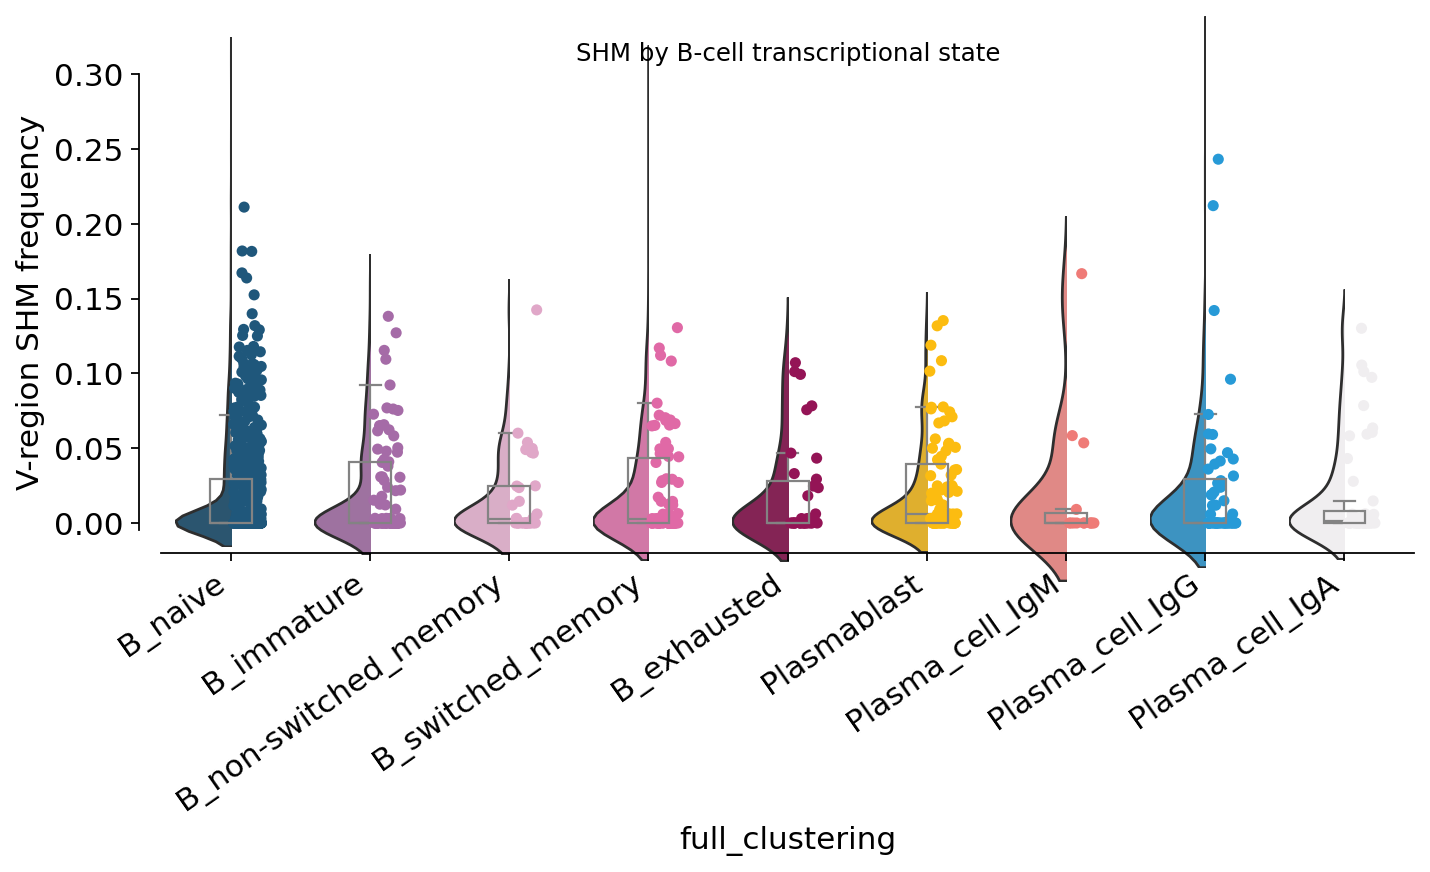

In [32]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ov.pl.half_violin_boxplot(adata, keys="mu_freq", groupby="full_clustering",
                          ax=ax, show=False)
ax.set_ylim(-0.005, 0.30)
ax.set_ylabel("V-region SHM frequency")
ax.set_title("SHM by B-cell transcriptional state", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
fig.subplots_adjust(left=0.10, right=0.97, top=0.92, bottom=0.30)
plt.show()

SHM in transcriptional states is weaker than by isotype — the median sits
near 0 in most clusters because the dataset is dominated by IgM-dominant
contigs even in some GEX-defined switched populations (the GEX-vs-VDJ
discordance from section 10). But the means and upper tails still rise from
naive → switched memory → plasmablast / plasma cells, reproducing the textbook
affinity-maturation gradient.

## 15. Naive vs memory call from SHM

A canonical sanity check: a `mu_freq < 0.01` call (the ~1 % SHM threshold from
the Immcantation literature) splits the repertoire into a "naive-like"
(unmutated) and an "antigen-experienced" (mutated) compartment, and the call
*should* line up with the GEX `B_naive` label.

In [33]:
adata.obs["shm_call"] = pd.Categorical(
    np.where(adata.obs["mu_freq"].fillna(0) < 0.01, "naive-like (<1%)",
             "experienced (≥1%)"),
    categories=["naive-like (<1%)", "experienced (≥1%)"],
)
tbl = pd.crosstab(adata.obs["full_clustering"], adata.obs["shm_call"],
                  normalize="index").round(3)
print("SHM-based naive call vs GEX cluster:")
print(tbl)

SHM-based naive call vs GEX cluster:
shm_call               naive-like (<1%)  experienced (≥1%)
full_clustering                                           
B_naive                           0.672              0.328
B_immature                        0.679              0.321
B_non-switched_memory             0.638              0.362
B_switched_memory                 0.632              0.368
B_exhausted                       0.663              0.337
Plasmablast                       0.641              0.359
Plasma_cell_IgM                   0.711              0.289
Plasma_cell_IgG                   0.631              0.369
Plasma_cell_IgA                   0.662              0.338


**B_naive sits at ~67 % naive-like by SHM** — the GEX and BCR definitions
agree most of the time but not perfectly. The ~33 % of GEX-naive cells called
"experienced" by SHM are partly real — some GEX-naive-like cells are early
memory cells whose transcriptome hasn't fully diverged — and partly the
GEX-vs-VDJ contig discordance from section 10. Inversely, all the memory and
plasma clusters still carry a sizeable "naive-like" fraction, because in this
5 k subset the median per-cell `mu_freq` is dominated by the rank-1 IgM contig
even in switched populations (a known limitation of UMI-rank chain selection).
A dandelion-style `c_call`-aware extraction is the canonical fix.

## 16. The COVID severity gradient

The Stephenson cohort spans **outpatient → ICU-intubated**. We ask three
questions in turn: does clonal expansion track severity? Does subclass usage
(IgG1 in particular) shift with severity? Does mean SHM shift with severity?

In [34]:
sev_order = ["Staff screening", "Ward_noO2", "Ward_O2", "Ward_NIV",
             "ITU_O2", "ITU_NIV", "ITU_intubated"]
adata.obs["Status_on_day_collection"] = pd.Categorical(
    adata.obs["Status_on_day_collection"], categories=sev_order
)
exp_sev = adata.obs.groupby("Status_on_day_collection",
                            observed=True)["clone_id_h_size"] \
    .apply(lambda s: (s >= 2).mean()).reindex(sev_order).round(3)
print("share in expanded clones by severity:")
print(exp_sev)

share in expanded clones by severity:
Status_on_day_collection
Staff screening    0.033
Ward_noO2          0.070
Ward_O2            0.120
Ward_NIV           0.188
ITU_O2             0.044
ITU_NIV            0.018
ITU_intubated      0.043
Name: clone_id_h_size, dtype: float64


In [35]:
# IgG1 fraction per severity
iso_sev = pd.crosstab(adata.obs["Status_on_day_collection"],
                      adata.obs["isotype"], normalize="index")
iso_sev = iso_sev.reindex(sev_order)
print("Subclass shares by severity:")
print(iso_sev.round(3))

Subclass shares by severity:
isotype                     IgM    IgD   IgG1   IgG2   IgG3   IgG4   IgA1  \
Status_on_day_collection                                                    
Staff screening           0.734  0.041  0.067  0.022  0.004  0.000  0.090   
Ward_noO2                 0.675  0.059  0.144  0.015  0.015  0.000  0.073   
Ward_O2                   0.600  0.051  0.166  0.016  0.018  0.002  0.129   
Ward_NIV                  0.490  0.071  0.308  0.008  0.016  0.004  0.083   
ITU_O2                    0.477  0.057  0.310  0.017  0.011  0.006  0.103   
ITU_NIV                   0.826  0.066  0.043  0.003  0.015  0.000  0.043   
ITU_intubated             0.711  0.068  0.109  0.006  0.019  0.002  0.065   

isotype                    IgA2  
Status_on_day_collection         
Staff screening           0.041  
Ward_noO2                 0.018  
Ward_O2                   0.020  
Ward_NIV                  0.020  
ITU_O2                    0.017  
ITU_NIV                   0.005  
ITU_i

In [36]:
shm_sev = adata.obs.groupby("Status_on_day_collection",
                                observed=True)["mu_freq"].mean() \
    .reindex(sev_order).round(4)
print("mean V-region SHM by severity:")
print(shm_sev)

mean V-region SHM by severity:
Status_on_day_collection
Staff screening    0.0249
Ward_noO2          0.0183
Ward_O2            0.0219
Ward_NIV           0.0265
ITU_O2             0.0213
ITU_NIV            0.0118
ITU_intubated      0.0209
Name: mu_freq, dtype: float64


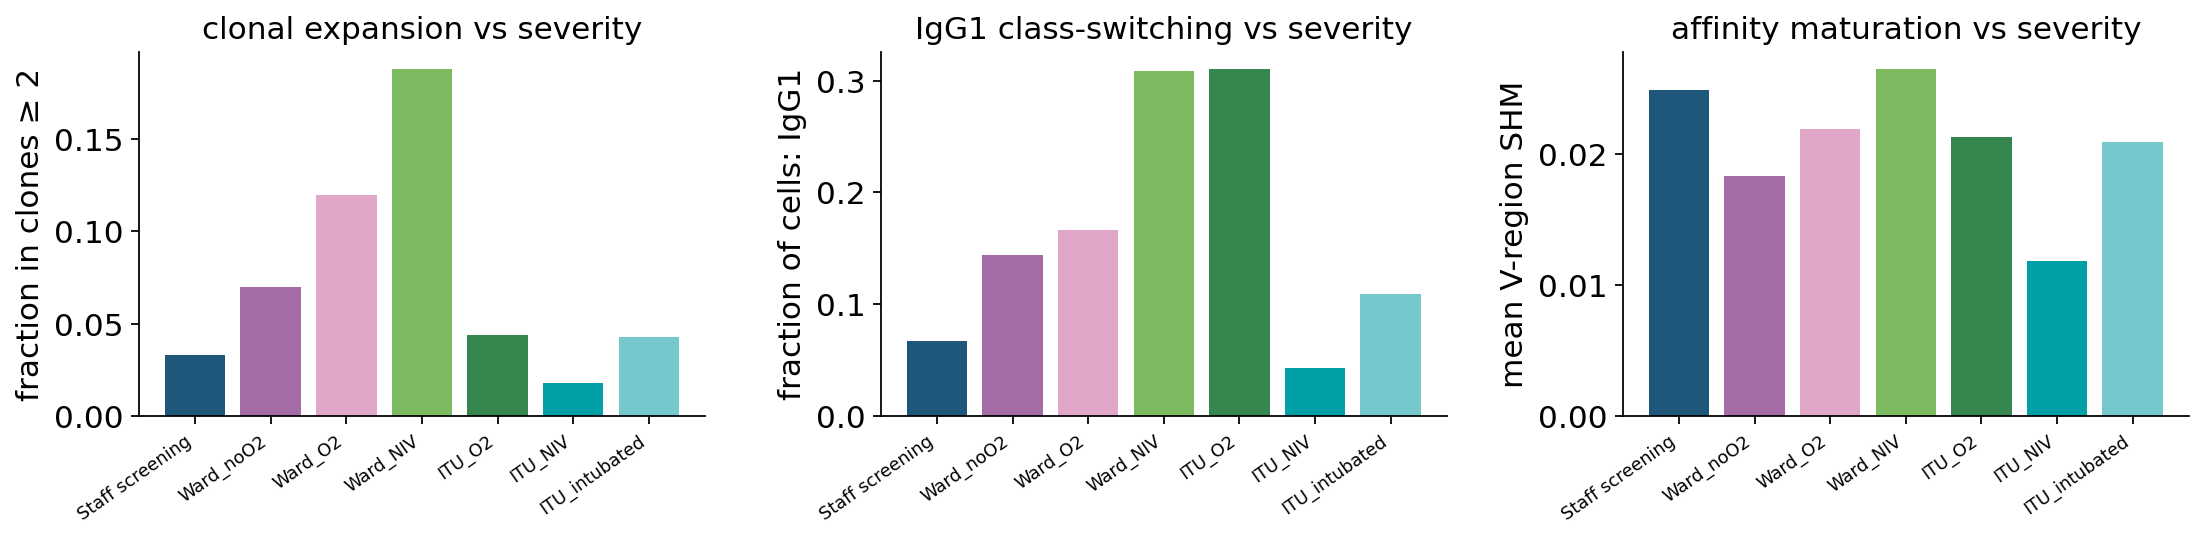

In [37]:
# Three per-group summary statistics — each panel is one value per severity
# (a fraction, a fraction, a mean). Plain matplotlib bars with the ov palette
# are the right tool here — bardotplot/violin_box are designed for per-cell
# distributions, not single summary values.
from omicverse.pl._palette import palette_28
sc_color = palette_28[:len(sev_order)]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].bar(range(len(sev_order)), exp_sev.values, color=sc_color)
axes[0].set_ylabel("fraction in clones ≥ 2")
axes[0].set_title("clonal expansion vs severity")
axes[1].bar(range(len(sev_order)), iso_sev["IgG1"].values, color=sc_color)
axes[1].set_ylabel("fraction of cells: IgG1")
axes[1].set_title("IgG1 class-switching vs severity")
axes[2].bar(range(len(sev_order)), shm_sev.values, color=sc_color)
axes[2].set_ylabel("mean V-region SHM")
axes[2].set_title("affinity maturation vs severity")
for a in axes:
    a.set_xticks(range(len(sev_order)))
    a.set_xticklabels(sev_order, rotation=35, ha="right", fontsize=8)
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Three observations:

- **Clonal expansion peaks at moderate disease**, not at the most-severe end:
  the share of cells in expanded clones rises from ~3 % in staff to ~19 % at
  Ward-NIV, then **collapses to 2–4 %** in the ITU groups. This reproduces
  one of Stephenson 2021's key BCR findings — the most severely ill patients
  show **B-cell dysregulation and lymphopenia** that flatten the antigen-driven
  clonal-expansion signal. A productive humoral response correlates with
  moderate, not maximal, disease severity. (The SHM-aware hierarchical
  clustering picks this up more clearly than exact-CDR3 — the peak is ~19 %
  here vs ~14 % with exact-CDR3.)
- **IgG1 class-switching also peaks at moderate severity**, going from ~7 % in
  staff to ~31 % at Ward-NIV / ITU-O2, then dropping at ITU-NIV and -intubated.
  This is the molecular counterpart of the expansion peak — class-switched
  B cells dominate the productive response and they too are depleted in
  critical disease.
- **Mean SHM is roughly flat across severity** (1.2–2.7 %). Affinity maturation
  is governed by germinal-centre kinetics that play out over weeks, so a
  single-timepoint snapshot of acute COVID-19 doesn't see a clean severity
  gradient on this axis — SHM is much more sensitive to *isotype* (section 12)
  than to acute clinical state.

(Caveat: IgA1 / IgA2 — the Stephenson paper reports a selective IgA2 loss in
symptomatic disease — is hard to resolve in this 5,000-cell subset because IgA2
is rare (≈60 cells total). The published finding is from the full 150 k-cell
cohort and isn't expected to reproduce reliably at tutorial scale.)

## 17. Where to go next

The single-cell side is the natural front-end for ov.airr's BCR pipeline; the
heavy-chain table you just built (`db`, `db_h`) plugs directly into the rest of
the B-cell stack covered in the **bulk BCR tutorial** (`t_airr_03_bcr.ipynb`):

| Question | `ov.airr` call |
|---|---|
| Selection signal in CDR vs FWR (BASELINe) | `ov.airr.baseline_selection(db_h)` |
| Reconstruct a lineage tree of one expanded clone | `ov.airr.lineage_trees(db_h_subset)` |
| Per-gene SHM targeting model | `ov.airr.shm_targeting(db_h)` |
| Novel-allele inference + Ig genotyping | `ov.airr.find_novel_alleles`, `ov.airr.infer_genotype` |
| Hill-diversity profile | `ov.airr.hill_diversity(db_h, clone='clone_id_h')` |

The fact that BCR analysis sits on **the same AnnData object** as the
transcriptome means everything you computed here — `clone_id_h`, `isotype`,
`mu_freq`, `expanded`, `shm_call` — is a normal `adata.obs` column that
composes with `ov.pl.embedding`, DEG analysis, trajectory inference and the
rest of the omicverse single-cell stack. Single-cell BCR is just one more
axis of the same cell.
